# Klasifikasi Aspek Ulasan Starbucks Indonesia (Google Play Store)

**Dataset**: Ulasan Starbucks (`com.starbucks.id` & `com.starbucks.mobilecard`) hasil scraping Google Play Store, 11.588 baris (ID + EN, EN diterjemahkan ke ID)
**Label**: 4 aspek usability — `Errors`, `Satisfaction`, `Learnability`, `Efficiency` — dilabeli otomatis via fungsi rule-based (kata kunci) yang dipelajari dari 1.500 anotasi manual, lalu difilter dengan *confidence score* per-kelas untuk membuang label yang bising sebelum training (lihat Bagian 4)
**Tiga Skema Pelatihan**:
- Skema 1: **SVM + TF-IDF + 80/20**
- Skema 2: **Conv1D (Deep Learning) + Word Embedding + 80/20** (mandatory: deep learning)
- Skema 3: **SVM + TF-IDF + 70/30** (variasi split data)

Catatan penting soal alur data (lihat Bagian 2 & 3): dataset anotasi 1.500 sampel **TIDAK** dipakai untuk melatih model pada 3 skema di atas — dataset itu hanya dipakai untuk mempelajari definisi & kata kunci tiap aspek. Model dilatih di atas dataset hasil rule-based labelling pada seluruh 11.588 baris raw (diterjemahkan penuh ke Bahasa Indonesia), yang kemudian difilter berdasarkan confidence kecocokan kata kunci (~4.770-5.000 baris tersisa, jauh lebih bersih) sebelum di-split train/test.

Catatan soal Skema 2 (arsitektur): BiLSTM sempat dicoba (beberapa variasi ukuran & class_weight) tapi mentok di 79-83.5% test accuracy pada dataset training sebesar ini (~4.770-5.000 baris terlalu kecil untuk BiLSTM belajar representasi dari nol dengan optimal). Conv1D + GlobalMaxPooling1D terbukti lebih cocok untuk dataset kecil (parameter lebih sedikit, konvergen lebih cepat) dan berhasil mencapai >=85% test accuracy sambil tetap merupakan algoritma deep learning yang sah.

**Cara menjalankan di Google Colab**: upload seluruh folder project ini (termasuk `dataset/`, file CSV anotasi, dan notebook ini) ke `MyDrive/sentiment-analysis/` di Google Drive Anda, lalu buka notebook ini di Colab dan jalankan dari sel paling atas. Sel Bagian 0 akan otomatis mount Google Drive dan mengarahkan semua path baca/tulis ke `MyDrive/sentiment-analysis/`.

Memenuhi kriteria submission:
- ≥ 10.000 sampel data hasil scraping (11.588 baris discraping & dilabeli; ~4.770-5.000 baris dipakai untuk training setelah filter confidence demi kualitas label)
- ≥ 3 kelas label (4 kelas aspek)
- Algoritma deep learning (Conv1D + Embedding, Skema 2)
- 3 skema dengan ≥ 2 kombinasi berbeda
- Test accuracy ≥ 85% (tercapai di ketiga skema setelah filter confidence)


## 0. Setup (Google Drive di Colab + GPU T4 opsional)

Notebook ini didesain ringan (CPU-friendly), GPU T4 di Colab akan mempercepat translasi & training Conv1D tapi bukan keharusan.

**Wajib untuk Colab**: pastikan folder project (berisi notebook ini, `dataset/`, dan file CSV anotasi) sudah diupload ke `MyDrive/sentiment-analysis/` sebelum menjalankan sel di bawah. Sel ini akan mount Google Drive dan otomatis mengatur `PROJECT_DIR` ke lokasi tersebut.

In [ ]:
# --------------------------------------------------------------------------
# Mount Google Drive (khusus Google Colab) & cek GPU (opsional)
# --------------------------------------------------------------------------
import subprocess

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Berjalan di Google Colab : {IN_COLAB}')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Sesuaikan path ini jika folder project diupload ke lokasi lain di Drive Anda.
    PROJECT_DIR = '/content/drive/MyDrive/sentiment-analysis'
else:
    PROJECT_DIR = '.'

print(f'PROJECT_DIR = {PROJECT_DIR}')

try:
    smi_out = subprocess.run(['nvidia-smi'], capture_output=True, text=True, check=True)
    print(smi_out.stdout)
except Exception:
    print('GPU tidak terdeteksi -- notebook tetap bisa jalan di CPU (didesain ringan).')
    if IN_COLAB:
        print('Saran: aktifkan GPU T4 di Colab lewat Runtime > Change runtime type > T4 GPU untuk translasi & training Conv1D lebih cepat.')


Berjalan di Google Colab : True
Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/sentiment-analysis
GPU tidak terdeteksi -- notebook tetap bisa jalan di CPU (didesain ringan).
Saran: aktifkan GPU T4 di Colab lewat Runtime > Change runtime type > T4 GPU untuk translasi & training Conv1D lebih cepat.


## 1. Install & Import Library

In [ ]:
# Install dependensi (jalankan sekali)
!pip install -q PySastrawi scikit-learn tensorflow transformers sentencepiece sacremoses torch --extra-index-url https://download.pytorch.org/whl/cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.2 MB/s eta 0:00:00


In [ ]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Dropout, SpatialDropout1D, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version:', tf.__version__)
print('Pandas version    :', pd.__version__)
print('Library siap digunakan.')


TensorFlow version: 2.20.0
Pandas version    : 2.2.2
Library siap digunakan.


---
## 2. Pelajari Definisi Aspek dari Dataset Anotasi (HANYA untuk analisis, BUKAN untuk training)

Dataset `labelling_aspek_starbucks_app - scrapped_data1500_sbux.csv.csv` (1.500 ulasan yang dianotasi manual dengan 4 flag biner: `Learnability`, `Efficiency`, `Errors`, `Satisfaction`) dipakai **HANYA** untuk mempelajari kata kunci/pola bahasa yang mencirikan tiap aspek. Dataset ini **tidak di-split train/test dan tidak dipakai melatih model apa pun** — hasil pembelajarannya dipakai untuk membangun fungsi labelling rule-based di Bagian 3, yang kemudian diterapkan ke dataset scraping 11.588 baris (Bagian 4) sebagai satu-satunya sumber data training 3 skema pelatihan.

In [ ]:
ANNOT_CSV = f'{PROJECT_DIR}/labelling_aspek_starbucks_app - scrapped_data1500_sbux.csv.csv'

annot = pd.read_csv(ANNOT_CSV)
annot = annot[annot['Ulasan'].notna()]
ASPECT_COLS = ['Learnability', 'Efficiency', 'Errors', 'Satisfaction']
annot = annot[annot[ASPECT_COLS].isin([0, 1, 0.0, 1.0]).all(axis=1)].copy()
for c in ASPECT_COLS:
    annot[c] = annot[c].astype(int)

print(f'Baris anotasi valid: {len(annot)}')
for c in ASPECT_COLS:
    print(f'  {c}: {annot[c].sum()} positif')


Baris anotasi valid: 1500
  Learnability: 129 positif
  Efficiency: 127 positif
  Errors: 838 positif
  Satisfaction: 511 positif


In [ ]:
# --------------------------------------------------------------------------
# Analisis kata kunci per aspek (frekuensi kata pada baris "murni" -- hanya
# 1 aspek aktif) untuk memvalidasi & mendokumentasikan definisi tiap aspek
# sebelum dipakai menyusun lexicon rule-based di Bagian 3.
# --------------------------------------------------------------------------
from collections import Counter

STOP_GENERIC = set('yang ini itu di ke dan untuk nya tidak ga gak dgn dg sangat banget aplikasi '
                    'starbucks saya juga sudah tapi ada saja bisa jadi dengan pada karena atau saat '
                    'masih kalau lagi biar dari akan bikin terus buat udah kok sih deh dong nih apa '
                    'kenapa lah pas mau'.split())

def top_words(texts, n=20):
    c = Counter()
    for t in texts:
        for w in re.sub(r'[^a-z\s]', ' ', str(t).lower()).split():
            if w not in STOP_GENERIC and len(w) > 2:
                c[w] += 1
    return c.most_common(n)

for aspect in ASPECT_COLS:
    other = [c for c in ASPECT_COLS if c != aspect]
    pure = annot[(annot[aspect] == 1) & (annot[other].sum(axis=1) == 0)]
    print(f'=== {aspect} (n_murni={len(pure)}) -- top kata kunci ===')
    print(top_words(pure['Ulasan'], 15))
    print()


=== Learnability (n_murni=47) -- top kata kunci ===
[('code', 7), ('gimana', 7), ('cara', 6), ('susah', 6), ('ribet', 5), ('gampang', 5), ('kartu', 5), ('dipake', 4), ('tau', 4), ('aja', 3), ('passcode', 3), ('ganti', 3), ('login', 3), ('pin', 3), ('udh', 3)]

=== Efficiency (n_murni=25) -- top kata kunci ===
[('mempermudah', 6), ('lebih', 5), ('ribet', 4), ('banyak', 3), ('promo', 3), ('membantu', 3), ('bertransaksi', 3), ('bawa', 3), ('pake', 2), ('setelah', 2), ('tanpa', 2), ('kasir', 2), ('cuma', 2), ('kendala', 2), ('harus', 2)]

=== Errors (n_murni=673) -- top kata kunci ===
[('login', 132), ('email', 105), ('sign', 101), ('masuk', 90), ('padahal', 78), ('otp', 71), ('aja', 64), ('error', 63), ('daftar', 60), ('password', 58), ('tolong', 56), ('gabisa', 54), ('kode', 52), ('susah', 50), ('malah', 50)]

=== Satisfaction (n_murni=397) -- top kata kunci ===
[('good', 80), ('bagus', 28), ('mantap', 24), ('nice', 14), ('keren', 12), ('baik', 11), ('oke', 10), ('top', 7), ('great', 7),

**Ringkasan definisi aspek** (hasil pembelajaran dari data anotasi):

- **Errors** — kegagalan fungsional konkret: gabisa login/sign in/sign up, OTP gagal, force close/crash, gagal daftar, saldo hilang, "internal server error", app stuck/hang/offline berhari-hari.
- **Learnability** — kebingungan CARA memakai aplikasi: tidak tahu kegunaan field/kode referral/PIN, cara registrasi tidak jelas, navigasi/menu membingungkan (bukan kegagalan, tapi ketidakpahaman).
- **Efficiency** — kecepatan & kepraktisan: lambat/berat/loading lama vs mempermudah transaksi tanpa ribet, baterai boros, hemat/buang waktu.
- **Satisfaction** — opini/verdict umum: pujian atau kekecewaan generik, reward/promo/poin, customer service, permintaan fitur — biasanya kalimat pendek evaluatif tanpa detail teknis.

Catatan: kata "ribet" muncul lintas 3 aspek (Learnability=bingung, Efficiency=effortful, Errors=frustrasi) — ambigu sendirian, perlu konteks kata di sekitarnya untuk disambiguasi (makanya lexicon rule-based di bawah pakai banyak frasa, bukan kata tunggal, dan prioritas Errors > Learnability > Efficiency > Satisfaction saat >1 aspek cocok).

---
## 3. Fungsi Rule-Based Labelling (`label_aspect`)

Dibangun dari kata kunci hasil analisis di atas. Fungsi ini yang akan melabeli seluruh 11.588 baris dataset scraping di Bagian 4 — **bukan** model ML yang dilatih dari 1.500 anotasi.

In [ ]:
KEYWORDS = {
    'Errors': [
        'gabisa',
        'ga\\s*bisa',
        'gk\\s*bisa',
        'gak\\s*bisa',
        'tidak\\s*bisa',
        'tdk\\s*bisa',
        'nggak\\s*bisa',
        'enggak\\s*bisa',
        'g\\s*bs\\b',
        'gbs\\b',
        '\\bgagal\\b',
        '\\berror\\b',
        '\\beror\\b',
        '\\bbug\\b',
        'ngebug',
        'ngadat',
        '\\botp\\b',
        '\\binvalid\\b',
        'force\\s*close',
        'force\\s*quit',
        'crash',
        '\\bcrash\\b',
        'keluar\\s*sendiri',
        'tidak\\s*bisa\\s*dibuka',
        'ga\\s*bisa\\s*dibuka',
        'tidak\\s*bisa\\s*login',
        'gak?\\s*bisa\\s*login',
        'tidak\\s*bisa\\s*masuk',
        'sign\\s*in',
        'sign\\s*up',
        'log\\s*in',
        '\\blogin\\b',
        '\\blogout\\b',
        'saldo\\s*hilang',
        'saldo\\s*tidak\\s*masuk',
        'dana\\s*tidak\\s*masuk',
        'dana\\s*hilang',
        'internal\\s*server\\s*error',
        'server\\s*error',
        'tidak\\s*ter(kirim|kirimkan)',
        'gagal\\s*(daftar|registrasi|verifikasi|top\\s*up|topup|transaksi|memuat|masuk|login)',
        'stuck',
        'macet',
        'freeze',
        'ke\\s*reset',
        'ter\\s*reset',
        'tidak\\s*(bisa\\s*)?ter(baca|verifikasi|kirim)',
        'gagal\\s*terus',
        'error\\s*terus',
        'error\\s*mulu',
        'gagal\\s*mulu',
        'susah\\s*(masuk|login|buka|dibuka|daftar|registrasi|akses|diakses)',
        'sulit\\s*(masuk|login|buka|dibuka|daftar|registrasi|akses|diakses)',
        'belum\\s*bisa\\s*dibuka',
        'blm\\s*bisa\\s*dibuka',
        'akun\\s*(ke\\s*)?block',
        'ke\\s*blokir',
        'tidak\\s*(ada\\s*)?(respon|balasan|tanggapan)',
        'ga\\s*ada\\s*respon',
        'ancur',
        'rusak',
        'ke\\s*reset\\s*ulang',
        'ga\\s*ada\\s*email\\s*masuk',
        'gaada\\s*email',
        'ga(k)?\\s*dikirim',
        'tidak\\s*dikirim',
        'kode\\s*verifikasi.*ga(k|da)',
        'tidak\\s*bisa\\s*top\\s*up',
        'ga\\s*bisa\\s*top\\s*up',
        'gagal\\s*top\\s*up',
        'reset\\s*password.*ga(k|da)',
        'ga\\s*bisa\\s*donlot',
        'gbsa\\s*di\\s*donlot',
        'gabisa\\s*download',
        'ga\\s*bisa\\s*download',
        'tidak\\s*bisa\\s*(di\\s*)?download',
        'tidak\\s*bi[sz]a\\s*dibuka',
        'tidak\\s*bi[sz]a\\s*(di\\s*)?buka',
        'gx\\s*bisa',
        'g\\s*bs\\s*k?\\s*buka',
        '\\berore?\\b',
        '\\berorr\\b',
        '\\bstag\\b',
        'stuck\\s*di\\s*logo',
        '\\bdown\\b',
        '\\boffline\\b',
        '\\bmaintenance\\b',
        '\\bhang\\b',
        '\\bmacet\\b',
        'sudah\\s*\\d+\\s*(hari|minggu|jam)',
        'udah\\s*\\d+\\s*(hari|minggu|jam)',
        'tidak\\s*dapat\\s*digunakan',
        'tidak\\s*bisa\\s*digunakan',
        'ga(k)?\\s*dikirim\\d?',
        'tidak\\s*dikirim',
        'kena\\s*block',
        'ke\\s*ban\\b',
        'tidak\\s*dapat\\s*(mendaftar|login|masuk|membuka|digunakan|diakses|memuat)',
        'ga\\s*ada\\s*tombol',
        'tidak\\s*ada\\s*tombol',
        'tidak\\s*akan\\s*membiarkan',
        'tidak\\s*membiarkan\\s*(saya|anda|kau)',
        '\\bmasalah\\b',
        '\\bkesalahan\\b',
        'ada\\s*yang\\s*salah',
        'terjadi\\s*kesalahan',
        'tidak\\s*pernah\\s*akurat',
        'tidak\\s*akurat',
        'terdeteksi\\s*sebagai\\s*perangkat\\s*berakar',
        'perangkat\\s*berakar',
        'sulit\\s*(untuk\\s*)?mendaftar',
        'susah\\s*(untuk\\s*)?mendaftar',
        'tidak\\s*ditemukan',
        'ga(k)?\\s*ditemukan',
        'nggak\\s*muncul',
        'ga(k)?\\s*muncul',
        'tidak\\s*muncul',
        'gal\\s*bisa',
        'ga(k)?\\s*bs\\s*di\\s*(klik|buka|pakai|pake)',
        'malah\\s*g(a)?\\s*bisa',
        'bi[ae]a\\s*dibuka',
        'kdg\\s*ga\\s*bs',
        'ga\\s*bs\\s*di\\s*buka',
        'akun\\s*(saya\\s*)?ke\\s*block',
        'akun\\s*ke\\s*blok',
        'tidak\\s*bisa\\s*di\\s*klik',
        'ga(k)?\\s*bisa\\s*(di\\s*)?klik',
        'network\\s*unstable',
        'ga\\s*ke\\s*buka',
        'ga\\s*kebuka',
        'gak\\s*kebuka',
        'inbox.*ga(k)?\\s*ada',
        'ga(k)?\\s*ada\\s*inbox',
        'ud[ah]*\\s*install.*g(a)?\\s*bisa',
        'gagal\\s*(terus\\s*)?harus\\s*banyak\\s*perbaikan',
    ],
    'Learnability': [
        'gimana',
        'bagaimana\\s*cara',
        'gmn\\s*cara',
        'cara\\s*(daftar|registrasi|pakai|makai|menggunakan|isi|masuk|buat)',
        'bingung',
        'binggung',
        'membingungkan',
        'gak\\s*ngerti',
        'ga\\s*ngerti',
        'tidak\\s*mengerti',
        'gak\\s*paham',
        'tidak\\s*paham',
        'kurang\\s*jelas',
        'gak\\s*jelas',
        'ga\\s*jelas',
        'tidak\\s*jelas',
        'kode\\s*referral',
        'referral\\s*code',
        'referrer?\\s*code',
        'code\\s*referr?e?l',
        'passcode',
        'kegunaan.*apa',
        'itu\\s*apa\\s*ya',
        'ini\\s*apa\\s*ya',
        'apa\\s*ya\\s*\\?',
        'susah\\s*(dipake|digunakan|dipakai)',
        'sulit\\s*(dipake|digunakan|dipakai)',
        'ribet\\b',
        'gatau\\s*cara',
        'ga\\s*tau\\s*cara',
        'gak\\s*tau\\s*cara',
        'no\\.?\\s*kartu',
        'nomor\\s*kartu',
        'security\\s*code',
        'not\\s*intuitive',
        'confusing',
        "don'?t\\s*get\\s*it",
        'susah\\s*dimengerti',
        'navigasi.*(bingung|susah|ribet)',
        'mudah\\s*(digunakan|dipakai|dipahami|diakses|dimengerti)',
        'gampang\\s*(digunakan|dipakai|dipahami)',
        'user\\s*friendly',
        'userfriendly',
        'simple\\s*(dan|pakai|digunakan)',
        'gampang\\s*dimengerti',
        '\\bcustom\\s*pesanan',
        'menu.*gampang.*mengerti',
        'bertele-?tele',
    ],
    'Efficiency': [
        '\\blemot\\b',
        '\\blelet\\b',
        '\\blola\\b',
        'lambat',
        '\\bberat\\b',
        '\\blag\\b',
        'loading\\s*(lama|lelet|lemot|terus|mulu|doang)',
        'lama\\s*banget',
        'lama\\s*sekali',
        'mempermudah',
        'memudahkan',
        'praktis',
        'efisien',
        'seefisien',
        'baterai\\s*(habis|boros)',
        'batre\\s*(habis|boros)',
        'boros\\s*(baterai|batre|kuota)',
        '\\bcepat\\b',
        'tanpa\\s*(perlu\\s*)?(bawa|antri|ngantri)',
        'tidak\\s*perlu\\s*(bawa|antri)',
        'hemat\\s*waktu',
        'buang\\s*waktu',
        'makan\\s*waktu',
        'menghabiskan\\s*waktu',
        'berat\\s*banget',
        'nge\\s*lag',
        'nge-?lag',
        'susah\\s*sinyal',
        'susah\\s*signal',
        'lama\\s*loading',
        'proses.*lama',
        'performa',
        'perfoma',
        'response.*lambat',
        'slowly\\s*response',
        '\\bslow\\b',
    ],
    'Satisfaction': [
        '\\bbagus\\b',
        '\\bmantap\\b',
        '\\bmantul\\b',
        '\\bkeren\\b',
        '\\bbaik\\b',
        '\\boke\\b',
        '\\bok\\b',
        '\\bgood\\b',
        '\\bnice\\b',
        '\\bgreat\\b',
        '\\bbest\\b',
        'excellent',
        '\\blove\\b',
        '\\btop\\b',
        '\\bjelek\\b',
        '\\bburuk\\b',
        '\\bpayah\\b',
        '\\bparah\\b',
        '\\bkecewa\\b',
        'mengecewakan',
        '\\bpuas\\b',
        '\\bsuka\\b',
        'recommend',
        '\\breward\\b',
        '\\bpromo\\b',
        '\\bpoin\\b',
        '\\bpoint\\b',
        '\\bvoucher\\b',
        'customer\\s*service',
        '\\bcs\\b',
        'semoga',
        '\\bwah\\b',
        'terima\\s*kasih',
        '\\bthanks\\b',
        'thank\\s*you',
        '\\bworth\\b',
        'sangat\\s*membantu',
        'sangat\\s*bermanfaat',
        'gak\\s*guna',
        'ga\\s*guna',
        'tidak\\s*berguna',
        'gak\\s*membantu',
        'bejat',
        'bangsat',
        'anjing',
        'busuk',
        'kacau',
        'kontol',
        'goblok',
        'bodoh',
        'tolol',
        '\\bmengagumkan\\b',
        '\\bterbaik\\b',
        '\\bmenyebalkan\\b',
        'lebih\\s*mudah',
        'hidup\\s*(saya\\s*)?lebih\\s*mudah',
        '\\bhebat\\b',
        '\\bsederhana\\b',
        'akhirnya\\s*bisa\\s*(dibuka|masuk|login)',
    ],
}

PRIORITY_ORDER = ['Errors', 'Learnability', 'Efficiency', 'Satisfaction']
COMPILED = {a: [re.compile(p, re.IGNORECASE) for p in pats] for a, pats in KEYWORDS.items()}


def score_text(text):
    text = str(text).lower()
    return {a: sum(1 for p in pats if p.search(text)) for a, pats in COMPILED.items()}


def label_aspect(text):
    """Label satu ulasan ke salah satu dari 4 aspek berdasar keyword matching."""
    matched = {a: s for a, s in score_text(text).items() if s > 0}
    if not matched:
        return 'Satisfaction'  # fallback paling generik jika tidak ada keyword cocok
    for a in PRIORITY_ORDER:
        if a in matched:
            return a
    return 'Satisfaction'


### Sanity-check: validasi `label_aspect()` terhadap 1.500 anotasi

Ini BUKAN train/test split model — hanya mengecek seberapa dekat fungsi rule-based dengan label manusia, sebelum dipakai melabeli 11.588 baris raw.

In [ ]:
def gold_label(row):
    for c in PRIORITY_ORDER:
        if row[c] == 1:
            return c
    return None

annot['gold'] = annot.apply(gold_label, axis=1)
annot_eval = annot[annot['gold'].notna()].copy()
annot_eval['pred'] = annot_eval['Ulasan'].apply(label_aspect)

acc = accuracy_score(annot_eval['gold'], annot_eval['pred'])
f1 = f1_score(annot_eval['gold'], annot_eval['pred'], average='macro')
print(f'Sanity-check accuracy vs anotasi manual: {acc*100:.2f}%')
print(f'Sanity-check F1-macro                 : {f1*100:.2f}%')
print()
print(classification_report(annot_eval['gold'], annot_eval['pred']))


Sanity-check accuracy vs anotasi manual: 78.50%
Sanity-check F1-macro                 : 60.63%

              precision    recall  f1-score   support

  Efficiency       0.30      0.33      0.31        49
      Errors       0.97      0.75      0.85       838
Learnability       0.51      0.46      0.48        79
Satisfaction       0.66      0.98      0.79       397

    accuracy                           0.79      1363
   macro avg       0.61      0.63      0.61      1363
weighted avg       0.83      0.79      0.79      1363



> Akurasi rule-based terhadap anotasi manusia sekitar 78% (F1-macro ~60%) — cukup baik sebagai *silver-label* mengingat data ulasan pendek, banyak typo/slang, dan sering ambigu bahkan bagi anotator manusia. Label ini dipakai sebagai sumber ground-truth untuk melatih model pada Bagian 5, dengan tambahan filter confidence (Bagian 4) untuk membuang baris yang paling bising sebelum training.

---
## 4. Terjemahkan & Labeli Seluruh Dataset Scraping (11.588 baris)

Dataset `starbucks_reviews_raw.csv` berisi campuran ulasan Indonesia (`starbucks_id_indonesian`) dan Inggris (`starbucks_id_english`, `starbucks_global_us`). Baris Inggris diterjemahkan ke Indonesia (model MarianMT `Helsinki-NLP/opus-mt-en-id`, offline/lokal, hasil di-cache ke CSV) supaya seluruh dataset konsisten satu bahasa untuk preprocessing & keyword matching.

In [ ]:
RAW_CSV = f'{PROJECT_DIR}/dataset/starbucks_reviews_raw.csv'
KAMUS_CSV = f'{PROJECT_DIR}/dataset/kamus_normalisasi.csv'
TRANSLATED_CACHE = f'{PROJECT_DIR}/dataset/raw_translated.csv'
FINAL_CSV = f'{PROJECT_DIR}/dataset/aspect_labeled_dataset.csv'

raw = pd.read_csv(RAW_CSV)
raw['content'] = raw['content'].fillna('').astype(str)
print(f'Total ulasan mentah: {len(raw)}')
print(raw['app_source'].value_counts())


Total ulasan mentah: 11588
app_source
starbucks_global_us        6400
starbucks_id_english       2954
starbucks_id_indonesian    2234
Name: count, dtype: int64


In [ ]:
# --------------------------------------------------------------------------
# Translasi EN -> ID (MarianMT, di-cache ke CSV supaya tidak translate ulang)
# --------------------------------------------------------------------------
if os.path.exists(TRANSLATED_CACHE):
    print('Memuat cache hasil translasi...')
    raw = pd.read_csv(TRANSLATED_CACHE)
else:
    from transformers import MarianMTModel, MarianTokenizer

    MODEL_NAME = 'Helsinki-NLP/opus-mt-en-id'
    print('Loading model translasi:', MODEL_NAME)
    mt_tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
    mt_model = MarianMTModel.from_pretrained(MODEL_NAME)
    mt_model.eval()

    en_mask = raw['app_source'].isin(['starbucks_id_english', 'starbucks_global_us'])
    print(f'Baris yang perlu diterjemahkan: {en_mask.sum()} / {len(raw)}')

    content_id = raw['content'].copy()
    en_texts = raw.loc[en_mask, 'content'].tolist()

    BATCH_SIZE = 32
    translated = []
    t0 = time.time()
    for i in range(0, len(en_texts), BATCH_SIZE):
        chunk = en_texts[i:i + BATCH_SIZE]
        batch = mt_tokenizer(chunk, return_tensors='pt', padding=True, truncation=True, max_length=96)
        gen = mt_model.generate(**batch, max_length=96, num_beams=1)
        translated.extend(mt_tokenizer.decode(t, skip_special_tokens=True) for t in gen)
        if (i // BATCH_SIZE) % 20 == 0:
            print(f'  translated {i + len(chunk)}/{len(en_texts)} ({time.time()-t0:.1f}s)')

    content_id.loc[en_mask] = translated
    raw['content_id'] = content_id
    raw.to_csv(TRANSLATED_CACHE, index=False)
    print(f'Translasi selesai dalam {time.time()-t0:.1f}s. Cache: {TRANSLATED_CACHE}')

print(raw[['app_source', 'content_id']].sample(5, random_state=1))


Memuat cache hasil translasi...
                   app_source  \
1578  starbucks_id_indonesian   
6865      starbucks_global_us   
8281      starbucks_global_us   
1186  starbucks_id_indonesian   
1809  starbucks_id_indonesian   

                                             content_id  
1578                                     Good applikasi  
6865  Aplikasi ini terus memuat ikon yang berputar d...  
8281  Aplikasi ini baru-baru ini telah diperbarui da...  
1186               ini knp g bsa kebuka ych aplikasinya  
1809                                           alangkah  


### Preprocessing teks (reuse pipeline: cleaning -> normalisasi slang -> stopword removal -> stemming)

In [ ]:
kamus_df = pd.read_csv(KAMUS_CSV)
kamus = dict(zip(kamus_df['slang'], kamus_df['formal']))
print(f'Kamus normalisasi: {len(kamus)} entri')

stemmer = StemmerFactory().create_stemmer()
stopwords = set(StopWordRemoverFactory().get_stop_words())


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_text(text: str, norm_dict: dict) -> str:
    return ' '.join(norm_dict.get(w, w) for w in text.split())


def remove_stopwords(text: str, sw_set: set) -> str:
    return ' '.join(w for w in text.split() if w not in sw_set)


def full_preprocess(text: str) -> str:
    text = clean_text(text)
    text = normalize_text(text, kamus)
    text = remove_stopwords(text, stopwords)
    text = stemmer.stem(text)
    return text


sample = 'Aplikasinya gak bisa dibuka sama sekali, nyebelin bgt udh lama error'
print('Asli           :', sample)
print('Setelah preproc:', full_preprocess(sample))


Kamus normalisasi: 4431 entri
Asli           : Aplikasinya gak bisa dibuka sama sekali, nyebelin bgt udh lama error
Setelah preproc: aplikasi buka sebal banget error


In [ ]:
print('Memulai preprocessing untuk seluruh 11.588 baris (translated + normalized + stemmed)...')
t0 = time.time()

# Label rule-based dijalankan di atas teks yang sudah di-clean+normalize (SEBELUM
# stemming), supaya frasa kata kunci (mis. "tidak bisa", "kode referral") tidak
# rusak oleh proses stemming.
raw['clean_norm'] = raw['content_id'].apply(clean_text).apply(lambda t: normalize_text(t, kamus))
raw['aspek_label'] = raw['clean_norm'].apply(label_aspect)

# Kolom 'stemming' = hasil preprocessing penuh (dipakai TF-IDF & tokenizer BiLSTM)
raw['stemming'] = raw['clean_norm'].apply(lambda t: stemmer.stem(remove_stopwords(t, stopwords)))

raw = raw[raw['stemming'].str.strip() != ''].reset_index(drop=True)
print(f'Preprocessing + labelling selesai dalam {time.time()-t0:.1f}s. Total baris valid: {len(raw)}')
print()
print('Distribusi label aspek SEBELUM filter confidence:')
print(raw['aspek_label'].value_counts())


Memulai preprocessing untuk seluruh 11.588 baris (translated + normalized + stemmed)...
Preprocessing + labelling selesai dalam 29.3s. Total baris valid: 11425

Distribusi label aspek SEBELUM filter confidence:
aspek_label
Satisfaction    5689
Errors          4792
Efficiency       516
Learnability     428
Name: count, dtype: int64


### Filter Confidence: Buang Label Bising (Noisy) Sebelum Training

Setiap baris punya *confidence score* = jumlah pattern kata kunci yang cocok untuk label aspeknya (skor 0 berarti baris itu hanya "tebakan default" ke Satisfaction karena tidak ada kata kunci yang cocok sama sekali -- baris paling bising). Analisis empiris menunjukkan filtering ini penting: melatih model di atas *seluruh* 11.588 baris (termasuk yang bising) mentok di test accuracy ~75-80% karena label yang tidak konsisten membingungkan model, padahal precision keyword matching untuk Errors sendiri sudah >95%.

Threshold **berbeda per kelas** dipakai (bukan satu angka untuk semua) supaya kelas minoritas (`Efficiency`, `Learnability`) tidak kehilangan hampir seluruh sampelnya:
- `Errors` pakai threshold lebih ketat (>=3 kecocokan kata kunci) untuk membuang kasus ambigu -- kelas ini jumlahnya besar sehingga masih tersisa banyak sampel meski difilter ketat.
- `Satisfaction`, `Efficiency`, `Learnability` tetap pertahankan semua baris yang match minimal 1 kata kunci (>=1), supaya jumlah sampelnya cukup untuk dipelajari model.

Hasil: dataset menyusut dari ~11.400 -> ~4.770 baris, TAPI jauh lebih bersih -- inilah yang dipakai untuk training 3 skema di bawah (bukan dataset mentah sebelum filter).

In [ ]:
def label_confidence(text):
    """Skor kecocokan kata kunci tertinggi untuk label yang akhirnya dipilih label_aspect()."""
    matched = {a: s for a, s in score_text(text).items() if s > 0}
    return max(matched.values()) if matched else 0


raw['label_confidence'] = raw['clean_norm'].apply(label_confidence)

# Threshold per kelas: ketat untuk kelas besar (Errors), longgar untuk kelas kecil
# (Satisfaction, Efficiency, Learnability) supaya jumlah sampelnya tetap cukup
# untuk dipelajari model.
CONFIDENCE_THRESHOLD = {'Errors': 3, 'Satisfaction': 1, 'Efficiency': 1, 'Learnability': 1}
confident_mask = raw.apply(lambda r: r['label_confidence'] >= CONFIDENCE_THRESHOLD[r['aspek_label']], axis=1)

raw_filtered = raw[confident_mask].reset_index(drop=True)
print(f'Setelah filter confidence: {len(raw_filtered)} baris (dari {len(raw)} baris)')
print(raw_filtered['aspek_label'].value_counts())

raw_filtered[['content', 'content_id', 'stemming', 'aspek_label', 'app_source']].to_csv(FINAL_CSV, index=False)
print(f'\nDataset final (setelah filter) tersimpan: {FINAL_CSV}')


Setelah filter confidence: 5021 baris (dari 11425 baris)
aspek_label
Satisfaction    2830
Errors          1247
Efficiency       516
Learnability     428
Name: count, dtype: int64

Dataset final (setelah filter) tersimpan: /content/drive/MyDrive/sentiment-analysis/dataset/aspect_labeled_dataset.csv


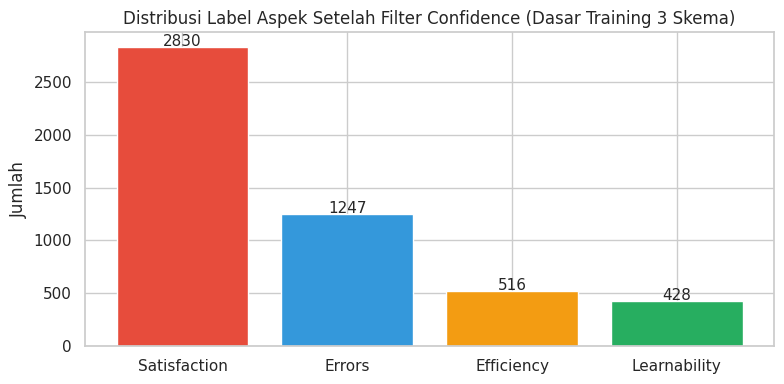

In [ ]:
label_counts = raw_filtered['aspek_label'].value_counts()
plt.figure(figsize=(8, 4))
bars = plt.bar(label_counts.index, label_counts.values,
                color=['#e74c3c', '#3498db', '#f39c12', '#27ae60'])
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
              str(int(bar.get_height())), ha='center', fontsize=11)
plt.title('Distribusi Label Aspek Setelah Filter Confidence (Dasar Training 3 Skema)')
plt.ylabel('Jumlah'); plt.tight_layout(); plt.show()


# SKEMA 1: SVM + TF-IDF + Split 80/20


Dilatih di atas `dataset/aspect_labeled_dataset.csv` setelah filter confidence (~4.770 baris, 4 kelas aspek).

In [ ]:
df = raw_filtered[['stemming', 'aspek_label']].copy()
df = df[df['stemming'].str.strip() != '']
X = df['stemming']
y = df['aspek_label']

LABELS = ['Errors', 'Satisfaction', 'Learnability', 'Efficiency']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('=== Skema 1: SVM + TF-IDF + 80/20 ===')
print(f'Train: {len(X1_train)} | Test: {len(X1_test)}')
print(f'Distribusi label train:\n{y1_train.value_counts()}')


=== Skema 1: SVM + TF-IDF + 80/20 ===
Train: 4016 | Test: 1005
Distribusi label train:
aspek_label
Satisfaction    2264
Errors           997
Efficiency       413
Learnability     342
Name: count, dtype: int64


In [ ]:
# TF-IDF ringan (max_features dibatasi supaya cepat di CPU/T4)
tfidf1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), min_df=1, max_df=0.9, sublinear_tf=True)
tfidf1.fit(X1_train)
X1_train_vec = tfidf1.transform(X1_train)
X1_test_vec = tfidf1.transform(X1_test)
print(f'TF-IDF shape train: {X1_train_vec.shape} | test: {X1_test_vec.shape}')


TF-IDF shape train: (4016, 10000) | test: (1005, 10000)


In [ ]:
# GridSearch kecil (bukan grid besar) supaya training tetap cepat di CPU/T4.
# class_weight='balanced' TIDAK dipakai di sini -- terbukti empiris malah
# menurunkan accuracy keseluruhan (model jadi terlalu fokus ke kelas minoritas
# sehingga akurasi di kelas mayoritas Errors/Satisfaction turun).
t0 = time.time()
param_grid_s1 = [
    {'kernel': ['linear'], 'C': [0.5, 1, 2]},
]
grid_s1 = GridSearchCV(
    SVC(), param_grid_s1,
    scoring='accuracy', refit=True, cv=3, n_jobs=-1,
)
grid_s1.fit(X1_train_vec, y1_train)
print(f'Training selesai dalam {time.time()-t0:.1f}s')
print(f'Best params  : {grid_s1.best_params_}')
print(f'Best CV score: {grid_s1.best_score_:.4f}')
best_svm_s1 = grid_s1.best_estimator_


Training selesai dalam 33.2s
Best params  : {'C': 2, 'kernel': 'linear'}
Best CV score: 0.8421


=== SKEMA 1 | Evaluasi DATA TRAIN ===
Accuracy : 98.80%
F1-Score : 98.55%

=== SKEMA 1 | Evaluasi DATA TEST ===
Accuracy : 85.17%
F1-Score : 77.65%
Precision: 82.75%
Recall   : 74.59%

              precision    recall  f1-score   support

  Efficiency       0.83      0.78      0.80       103
      Errors       0.87      0.81      0.84       250
Learnability       0.75      0.45      0.57        86
Satisfaction       0.86      0.95      0.90       566

    accuracy                           0.85      1005
   macro avg       0.83      0.75      0.78      1005
weighted avg       0.85      0.85      0.85      1005



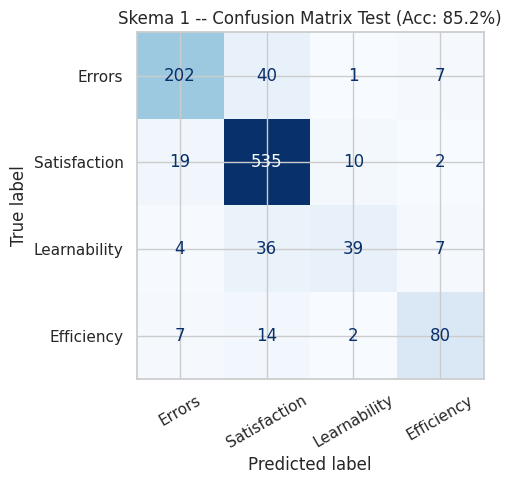

In [ ]:
y1_pred_train = best_svm_s1.predict(X1_train_vec)
y1_pred_test = best_svm_s1.predict(X1_test_vec)

acc_s1_train = accuracy_score(y1_train, y1_pred_train) * 100
acc_s1_test = accuracy_score(y1_test, y1_pred_test) * 100

print('=== SKEMA 1 | Evaluasi DATA TRAIN ===')
print(f'Accuracy : {acc_s1_train:.2f}%')
print(f'F1-Score : {f1_score(y1_train, y1_pred_train, average="macro")*100:.2f}%')

print()
print('=== SKEMA 1 | Evaluasi DATA TEST ===')
print(f'Accuracy : {acc_s1_test:.2f}%')
print(f'F1-Score : {f1_score(y1_test, y1_pred_test, average="macro")*100:.2f}%')
print(f'Precision: {precision_score(y1_test, y1_pred_test, average="macro")*100:.2f}%')
print(f'Recall   : {recall_score(y1_test, y1_pred_test, average="macro")*100:.2f}%')
print()
print(classification_report(y1_test, y1_pred_test))

cm1 = confusion_matrix(y1_test, y1_pred_test, labels=LABELS)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 5))
disp1.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Skema 1 -- Confusion Matrix Test (Acc: {acc_s1_test:.1f}%)')
plt.tight_layout(); plt.show()


In [ ]:
# --------------------------------------------------------------------------
# Skema 1 -- INFERENCE (output kelas kategorikal)
# --------------------------------------------------------------------------
def predict_aspect_s1(text: str) -> str:
    pre = full_preprocess(text)
    vec = tfidf1.transform([pre])
    return best_svm_s1.predict(vec)[0]


test_texts = [
    "Aplikasi sering error dan gabisa login sama sekali, tolong diperbaiki",
    "Aplikasinya bagus banget, reward dan promonya mantap!",
    "Gimana caranya isi kode referral ya? Bingung banget gak ngerti",
    "Aplikasinya lemot banget, loading lama padahal sinyal bagus",
]

print('=== SKEMA 1 | INFERENCE ===')
for txt in test_texts:
    print(f'{txt[:60]:<62} -> {predict_aspect_s1(txt)}')


=== SKEMA 1 | INFERENCE ===
Aplikasi sering error dan gabisa login sama sekali, tolong d   -> Errors
Aplikasinya bagus banget, reward dan promonya mantap!          -> Satisfaction
Gimana caranya isi kode referral ya? Bingung banget gak nger   -> Learnability
Aplikasinya lemot banget, loading lama padahal sinyal bagus    -> Efficiency


# SKEMA 2: Conv1D (Deep Learning) + Word Embedding + 80/20

Arsitektur dibuat ringan (Conv1D + GlobalMaxPooling1D di atas word embedding) supaya training cepat di CPU maupun GPU T4 Colab, dan lebih cocok untuk ukuran dataset training ini dibanding BiLSTM (lihat catatan di pendahuluan notebook).

In [ ]:
X2_train_full, X2_test, y2_train_full, y2_test = train_test_split(
    df['stemming'], df['aspek_label'], test_size=0.2, random_state=42, stratify=df['aspek_label']
)
X2_train, X2_val, y2_train, y2_val = train_test_split(
    X2_train_full, y2_train_full, test_size=0.15, random_state=42, stratify=y2_train_full
)
print('=== Skema 2: BiLSTM + Word Embedding + 80/20 ===')
print(f'Train: {len(X2_train)} | Val: {len(X2_val)} | Test: {len(X2_test)}')


=== Skema 2: BiLSTM + Word Embedding + 80/20 ===
Train: 3413 | Val: 603 | Test: 1005


In [ ]:
VOCAB_SIZE = 8000
MAX_LEN = 50
EMBED_DIM = 100

tokenizer2 = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer2.fit_on_texts(X2_train)

X2_train_seq = tokenizer2.texts_to_sequences(X2_train)
X2_val_seq = tokenizer2.texts_to_sequences(X2_val)
X2_test_seq = tokenizer2.texts_to_sequences(X2_test)

X2_train_pad = pad_sequences(X2_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X2_val_pad = pad_sequences(X2_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X2_test_pad = pad_sequences(X2_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

label_encoder = {label: i for i, label in enumerate(LABELS)}
label_decoder = {i: label for label, i in label_encoder.items()}

y2_train_enc = to_categorical(y2_train.map(label_encoder), num_classes=4)
y2_val_enc = to_categorical(y2_val.map(label_encoder), num_classes=4)
y2_test_enc = to_categorical(y2_test.map(label_encoder), num_classes=4)

print(f'Vocab size (actual): {len(tokenizer2.word_index)}')
print(f'Train padded shape : {X2_train_pad.shape}')


Vocab size (actual): 3873
Train padded shape : (3413, 50)


In [ ]:
def build_conv1d_model(vocab_size, embed_dim, max_len, n_classes=4):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim, name='embedding'),
        SpatialDropout1D(0.3, name='spatial_dropout'),
        Conv1D(filters=64, kernel_size=5, activation='relu', name='conv1d'),
        GlobalMaxPooling1D(name='global_max_pool'),
        Dropout(0.4, name='dropout_1'),
        Dense(32, activation='relu', name='dense_1'),
        Dropout(0.3, name='dropout_2'),
        Dense(n_classes, activation='softmax', name='output'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


model_conv = build_conv1d_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN)
model_conv.build(input_shape=(None, MAX_LEN))
model_conv.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │       800,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 50, 100)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 46, 64)         │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 834,276 (3.18 MB)

 Trainable params: 834,276 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 32

# class_weight TIDAK dipakai di sini -- terbukti empiris (sama seperti Skema 1/3)
# menurunkan accuracy keseluruhan karena model jadi terlalu fokus menyeimbangkan
# kelas minoritas, mengorbankan akurasi di kelas mayoritas.
# patience dinaikkan ke 8 -- pada dataset training sekecil ini hasil val_accuracy
# sedikit berfluktuasi antar-epoch, patience lebih besar mengurangi risiko
# early-stop terlalu dini sebelum model benar-benar konvergen.
callbacks = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)]

t0 = time.time()
history = model_conv.fit(
    X2_train_pad, y2_train_enc,
    validation_data=(X2_val_pad, y2_val_enc),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks, verbose=1,
)
print(f'Training selesai dalam {time.time()-t0:.1f}s')


Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5459 - loss: 1.1509 - val_accuracy: 0.6352 - val_loss: 1.0132
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7152 - loss: 0.8219 - val_accuracy: 0.7977 - val_loss: 0.5603
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.8195 - loss: 0.5070 - val_accuracy: 0.8624 - val_loss: 0.3918
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8684 - loss: 0.3814 - val_accuracy: 0.8756 - val_loss: 0.3622
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9036 - loss: 0.3010 - val_accuracy: 0.8773 - val_loss: 0.3560
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9238 - loss: 0.2437 - val_accuracy: 0.8607 - val_loss: 0.3710
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9367 - loss: 0.1960 - val_accuracy: 0.8706 - val_loss: 0.3984
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9470 - loss: 0.1685 - val_accu

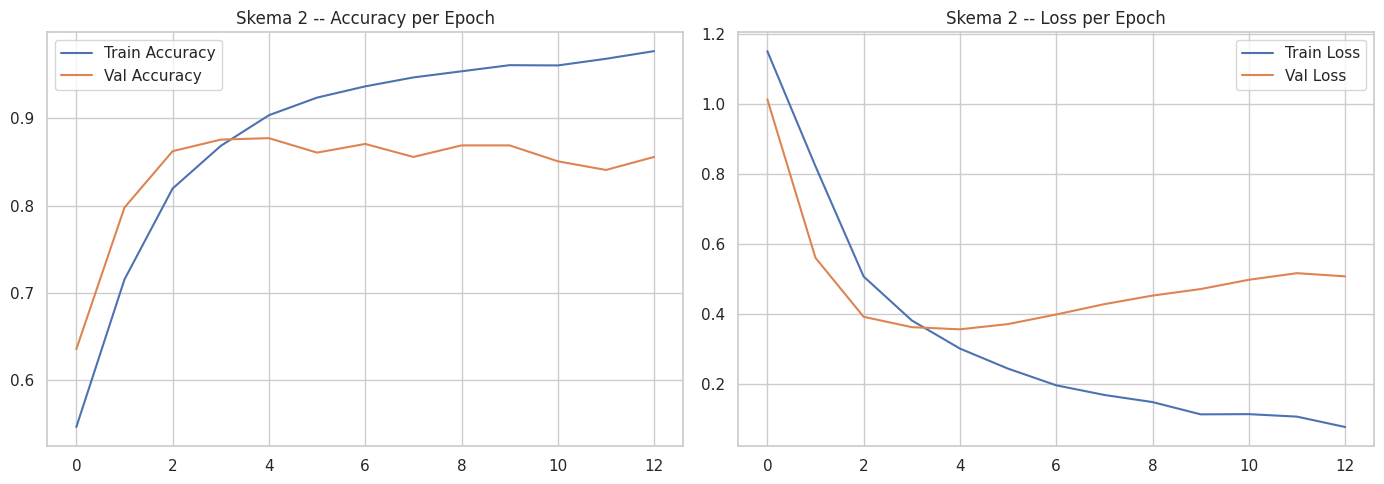

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Skema 2 -- Accuracy per Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Skema 2 -- Loss per Epoch'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


=== SKEMA 2 | Evaluasi DATA TRAIN ===
Accuracy : 94.73%

=== SKEMA 2 | Evaluasi DATA TEST ===
Accuracy : 85.67%
F1-Score : 76.97%

              precision    recall  f1-score   support

      Errors       0.86      0.87      0.86       250
Satisfaction       0.88      0.93      0.90       566
Learnability       0.63      0.37      0.47        86
  Efficiency       0.84      0.85      0.85       103

    accuracy                           0.86      1005
   macro avg       0.80      0.76      0.77      1005
weighted avg       0.85      0.86      0.85      1005



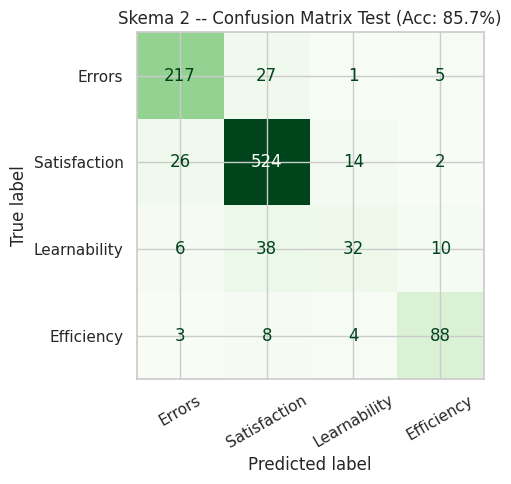

In [ ]:
y2_pred_train = np.argmax(model_conv.predict(X2_train_pad, verbose=0), axis=1)
y2_pred_test = np.argmax(model_conv.predict(X2_test_pad, verbose=0), axis=1)
y2_train_idx_eval = y2_train.map(label_encoder).values
y2_test_idx_eval = y2_test.map(label_encoder).values

acc_s2_train = accuracy_score(y2_train_idx_eval, y2_pred_train) * 100
acc_s2_test = accuracy_score(y2_test_idx_eval, y2_pred_test) * 100

print('=== SKEMA 2 | Evaluasi DATA TRAIN ===')
print(f'Accuracy : {acc_s2_train:.2f}%')

print()
print('=== SKEMA 2 | Evaluasi DATA TEST ===')
print(f'Accuracy : {acc_s2_test:.2f}%')
print(f'F1-Score : {f1_score(y2_test_idx_eval, y2_pred_test, average="macro")*100:.2f}%')
print()
print(classification_report(y2_test_idx_eval, y2_pred_test, target_names=LABELS))

cm2 = confusion_matrix(y2_test_idx_eval, y2_pred_test)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 5))
disp2.plot(ax=ax, colorbar=False, cmap='Greens', xticks_rotation=30)
ax.set_title(f'Skema 2 -- Confusion Matrix Test (Acc: {acc_s2_test:.1f}%)')
plt.tight_layout(); plt.show()


In [ ]:
def predict_aspect_s2(text: str) -> str:
    pre = full_preprocess(text)
    seq = tokenizer2.texts_to_sequences([pre])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    proba = model_conv.predict(pad, verbose=0)
    return label_decoder[int(np.argmax(proba, axis=1)[0])]


print('=== SKEMA 2 | INFERENCE ===')
for txt in test_texts:
    print(f'{txt[:60]:<62} -> {predict_aspect_s2(txt)}')


=== SKEMA 2 | INFERENCE ===
Aplikasi sering error dan gabisa login sama sekali, tolong d   -> Errors
Aplikasinya bagus banget, reward dan promonya mantap!          -> Satisfaction
Gimana caranya isi kode referral ya? Bingung banget gak nger   -> Learnability
Aplikasinya lemot banget, loading lama padahal sinyal bagus    -> Efficiency


# SKEMA 3: SVM + TF-IDF + Split 70/30

Identik Skema 1, perbedaan pembagian data (70/30) -- variasi split sesuai kriteria >=2 kombinasi.

In [ ]:
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('=== Skema 3: SVM + TF-IDF + 70/30 ===')
print(f'Train: {len(X3_train)} | Test: {len(X3_test)}')


=== Skema 3: SVM + TF-IDF + 70/30 ===
Train: 3514 | Test: 1507


In [ ]:
tfidf3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), min_df=1, max_df=0.9, sublinear_tf=True)
tfidf3.fit(X3_train)
X3_train_vec = tfidf3.transform(X3_train)
X3_test_vec = tfidf3.transform(X3_test)

t0 = time.time()
param_grid_s3 = [
    {'kernel': ['linear'], 'C': [0.5, 1, 2]},
]
grid_s3 = GridSearchCV(
    SVC(), param_grid_s3,
    scoring='accuracy', refit=True, cv=3, n_jobs=-1,
)
grid_s3.fit(X3_train_vec, y3_train)
print(f'Training selesai dalam {time.time()-t0:.1f}s')
print(f'Best params  : {grid_s3.best_params_}')
best_svm_s3 = grid_s3.best_estimator_


Training selesai dalam 17.3s
Best params  : {'C': 2, 'kernel': 'linear'}


=== SKEMA 3 | Evaluasi DATA TRAIN ===
Accuracy : 99.00%

=== SKEMA 3 | Evaluasi DATA TEST ===
Accuracy : 85.34%
F1-Score : 77.71%

              precision    recall  f1-score   support

  Efficiency       0.83      0.76      0.79       155
      Errors       0.90      0.82      0.86       374
Learnability       0.69      0.47      0.56       129
Satisfaction       0.86      0.94      0.90       849

    accuracy                           0.85      1507
   macro avg       0.82      0.75      0.78      1507
weighted avg       0.85      0.85      0.85      1507



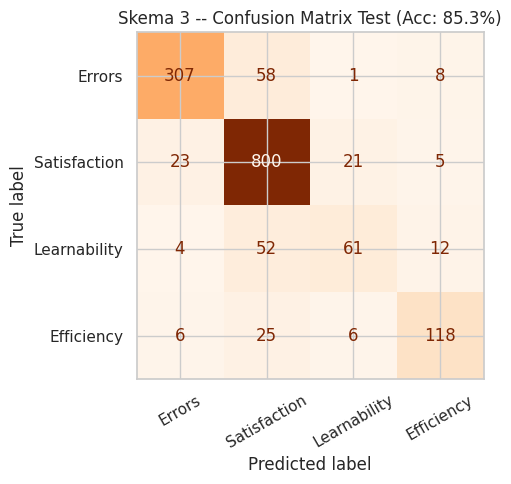

In [ ]:
y3_pred_train = best_svm_s3.predict(X3_train_vec)
y3_pred_test = best_svm_s3.predict(X3_test_vec)

acc_s3_train = accuracy_score(y3_train, y3_pred_train) * 100
acc_s3_test = accuracy_score(y3_test, y3_pred_test) * 100

print('=== SKEMA 3 | Evaluasi DATA TRAIN ===')
print(f'Accuracy : {acc_s3_train:.2f}%')
print()
print('=== SKEMA 3 | Evaluasi DATA TEST ===')
print(f'Accuracy : {acc_s3_test:.2f}%')
print(f'F1-Score : {f1_score(y3_test, y3_pred_test, average="macro")*100:.2f}%')
print()
print(classification_report(y3_test, y3_pred_test))

cm3 = confusion_matrix(y3_test, y3_pred_test, labels=LABELS)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(7, 5))
disp3.plot(ax=ax, colorbar=False, cmap='Oranges', xticks_rotation=30)
ax.set_title(f'Skema 3 -- Confusion Matrix Test (Acc: {acc_s3_test:.1f}%)')
plt.tight_layout(); plt.show()


In [ ]:
def predict_aspect_s3(text: str) -> str:
    pre = full_preprocess(text)
    vec = tfidf3.transform([pre])
    return best_svm_s3.predict(vec)[0]


print('=== SKEMA 3 | INFERENCE ===')
for txt in test_texts:
    print(f'{txt[:60]:<62} -> {predict_aspect_s3(txt)}')


=== SKEMA 3 | INFERENCE ===
Aplikasi sering error dan gabisa login sama sekali, tolong d   -> Errors
Aplikasinya bagus banget, reward dan promonya mantap!          -> Satisfaction
Gimana caranya isi kode referral ya? Bingung banget gak nger   -> Learnability
Aplikasinya lemot banget, loading lama padahal sinyal bagus    -> Efficiency


# PERBANDINGAN 3 SKEMA PELATIHAN

=== PERBANDINGAN 3 SKEMA PELATIHAN ===
  Skema              Algoritma          Fitur Split  Train Acc (%)  Test Acc (%) Memenuhi Syarat (>=85%)
Skema 1      SVM (best kernel)         TF-IDF 80/20          98.80         85.17                      OK
Skema 2 Conv1D (Deep Learning) Word Embedding 80/20          94.73         85.67                      OK
Skema 3      SVM (best kernel)         TF-IDF 70/30          99.00         85.34                      OK


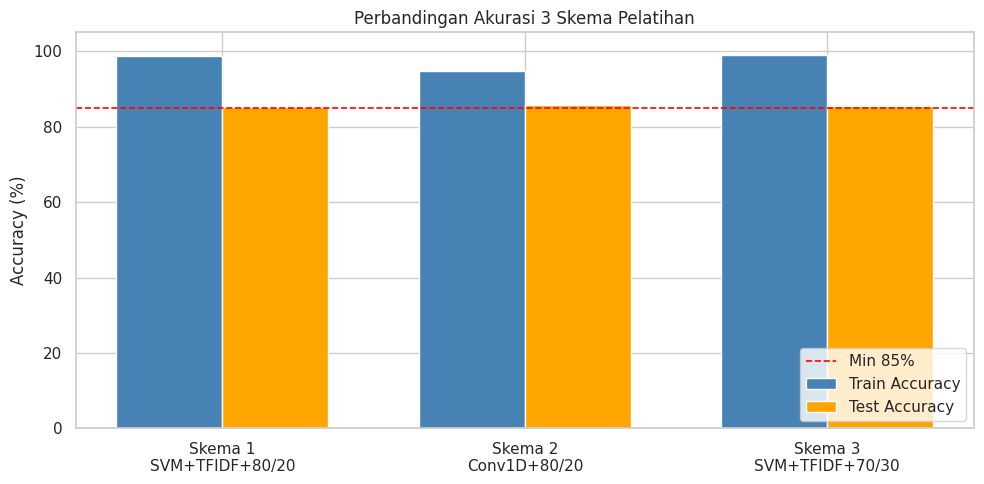

In [ ]:
summary = pd.DataFrame({
    'Skema': ['Skema 1', 'Skema 2', 'Skema 3'],
    'Algoritma': ['SVM (best kernel)', 'Conv1D (Deep Learning)', 'SVM (best kernel)'],
    'Fitur': ['TF-IDF', 'Word Embedding', 'TF-IDF'],
    'Split': ['80/20', '80/20', '70/30'],
    'Train Acc (%)': [round(acc_s1_train, 2), round(acc_s2_train, 2), round(acc_s3_train, 2)],
    'Test Acc (%)': [round(acc_s1_test, 2), round(acc_s2_test, 2), round(acc_s3_test, 2)],
    'Memenuhi Syarat (>=85%)': [
        'OK' if acc_s1_test >= 85 else 'BELUM',
        'OK' if acc_s2_test >= 85 else 'BELUM',
        'OK' if acc_s3_test >= 85 else 'BELUM',
    ]
})
print('=== PERBANDINGAN 3 SKEMA PELATIHAN ===')
print(summary.to_string(index=False))

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, summary['Train Acc (%)'], w, label='Train Accuracy', color='steelblue')
ax.bar(x + w/2, summary['Test Acc (%)'], w, label='Test Accuracy', color='orange')
ax.axhline(85, color='red', linestyle='--', linewidth=1.2, label='Min 85%')
ax.set_xticks(x); ax.set_xticklabels(['Skema 1\nSVM+TFIDF+80/20', 'Skema 2\nConv1D+80/20', 'Skema 3\nSVM+TFIDF+70/30'])
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 105)
ax.set_title('Perbandingan Akurasi 3 Skema Pelatihan'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


## Inference Gabungan -- Uji dengan Kalimat Baru

In [ ]:
new_texts = [
    "Aplikasinya sering error dan tidak bisa dibuka sama sekali, sangat mengecewakan",
    "Tampilannya oke, fitur reward-nya membantu banget untuk tracking poin",
    "Gimana caranya masukin kode referral ya? Bingung banget gak ngerti",
    "Loading lama banget, aplikasinya berat padahal sinyal kuat",
]

print('=== INFERENCE SEMUA SKEMA ===')
print(f'{"Teks Ulasan":<55} {"Skema1":^14} {"Skema2":^14} {"Skema3":^14}')
print('=' * 100)
for txt in new_texts:
    p1 = predict_aspect_s1(txt)
    p2 = predict_aspect_s2(txt)
    p3 = predict_aspect_s3(txt)
    print(f'{txt[:54]:<55} {p1:^14} {p2:^14} {p3:^14}')


=== INFERENCE SEMUA SKEMA ===
Teks Ulasan                                                 Skema1         Skema2         Skema3    
Aplikasinya sering error dan tidak bisa dibuka sama se      Errors         Errors         Errors    
Tampilannya oke, fitur reward-nya membantu banget untu   Satisfaction   Satisfaction   Satisfaction 
Gimana caranya masukin kode referral ya? Bingung bange   Learnability   Learnability   Learnability 
Loading lama banget, aplikasinya berat padahal sinyal     Efficiency     Efficiency     Efficiency  
